In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

In [51]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [52]:
df.shape

(1470, 35)

In [53]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [54]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [55]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [56]:
df.isnull().sum().sum()

np.int64(0)

In [57]:
df.duplicated().sum()

np.int64(0)

Data Understanding 

In [58]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [59]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Data Cleaning 

In [60]:
# Drop the unless columns that are not useful for prediction
df = df.drop(
    columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
)

In [61]:
df.shape

(1470, 31)

Separate X and y

In [62]:
X = df.drop(columns=["Attrition"])

X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,3,4,1,6,3,3,2,2,2,2


Create y

In [63]:
y = df["Attrition"]

y.head()

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object

Encoding

In [64]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [65]:
y.value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [66]:
categorical_columns = X.select_dtypes(include="object").columns

categorical_columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [67]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

In [68]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [69]:
X.shape

(1470, 44)

Train/Test Split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 44)
Testing data: (294, 44)


Feature Scaling

In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Handle Class Imbalance

In [73]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [74]:
# check before and after SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())


Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


Create KNN model


In [75]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_balanced, y_train_balanced)



,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [76]:
y_pred = knn.predict(X_test_scaled)
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 1])

Evaluate the Model

In [77]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

Accuracy: 0.6224489795918368
Precision: 0.21929824561403508
Recall: 0.5319148936170213
F1 Score: 0.3105590062111801


In [78]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[158  89]
 [ 22  25]]


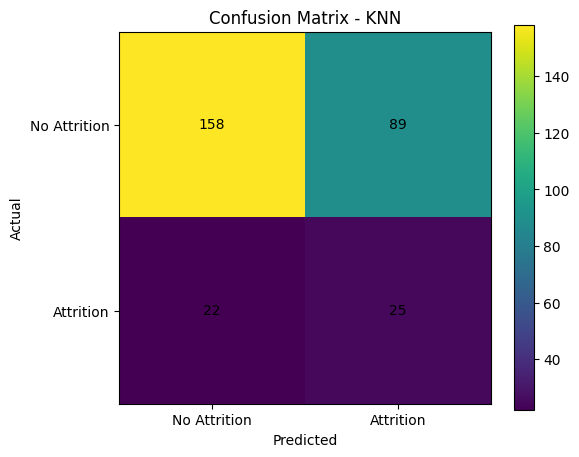

In [79]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Attrition", "Attrition"])
plt.yticks([0, 1], ["No Attrition", "Attrition"])

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.show()

In [80]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Attrition", "Attrition"]
    )
)

              precision    recall  f1-score   support

No Attrition       0.88      0.64      0.74       247
   Attrition       0.22      0.53      0.31        47

    accuracy                           0.62       294
   macro avg       0.55      0.59      0.53       294
weighted avg       0.77      0.62      0.67       294



Find the Best K

In [81]:
k_values = range(1, 21)

f1_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_balanced,
        y_train_balanced,
        cv=5,
        scoring="f1"
    )

    f1_scores.append(scores.mean())

Plot K vs F1 Score

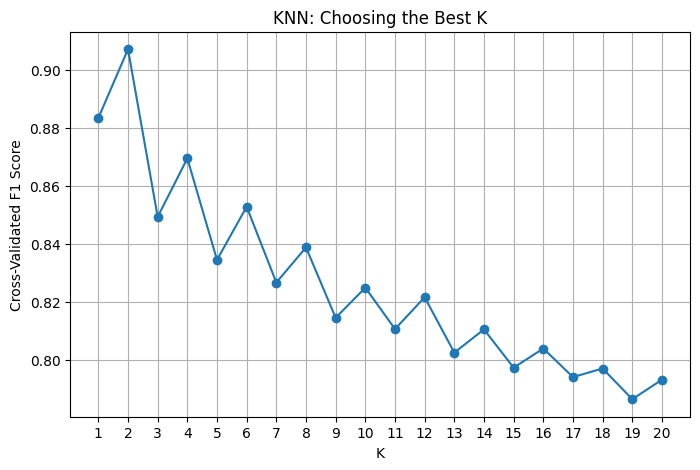

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, f1_scores, marker="o")

plt.xlabel("K")
plt.ylabel("Cross-Validated F1 Score")
plt.title("KNN: Choosing the Best K")

plt.xticks(range(1, 21))

plt.grid(True)

plt.show()

Find best K

In [83]:
best_k = k_values[np.argmax(f1_scores)]

print("Best K:", best_k)
print("Best F1 Score:", max(f1_scores))

Best K: 2
Best F1 Score: 0.9071919946080802


Create final model

In [84]:
knn_final = KNeighborsClassifier(
    n_neighbors=best_k
)

Train final model

In [85]:
knn_final.fit(
    X_train_balanced,
    y_train_balanced
)

,n_neighbors,2
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [86]:
y_pred_final = knn_final.predict(X_test_scaled)

In [88]:
accuracy = accuracy_score(y_test, y_pred_final)

print("Final Accuracy:", accuracy)

precision = precision_score(y_test, y_pred_final)

print("Final Precision:", precision)

recall = recall_score(y_test, y_pred_final)

print("Final Recall:", recall)

f1 = f1_score(y_test, y_pred_final)

print("Final F1 Score:", f1)

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["No Attrition", "Attrition"]
    )
)



Final Accuracy: 0.7789115646258503
Final Precision: 0.32
Final Recall: 0.3404255319148936
Final F1 Score: 0.32989690721649484
              precision    recall  f1-score   support

No Attrition       0.87      0.86      0.87       247
   Attrition       0.32      0.34      0.33        47

    accuracy                           0.78       294
   macro avg       0.60      0.60      0.60       294
weighted avg       0.78      0.78      0.78       294



ROC-AUC

Prediction probabilities

In [89]:
y_probability = knn_final.predict_proba(X_test_scaled)[:, 1]

In [90]:
auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.6246877422689292


ROC Curve

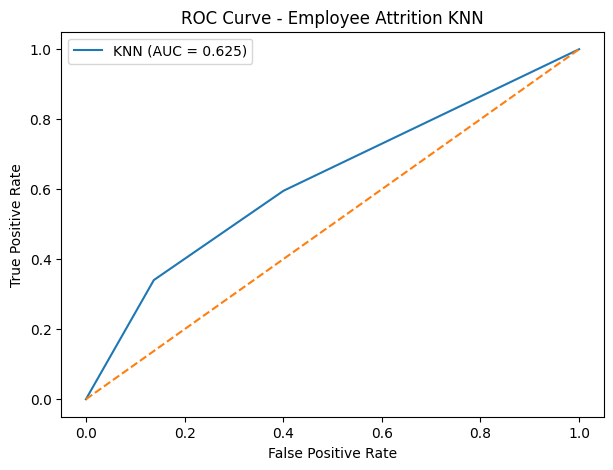

In [91]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"KNN (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Employee Attrition KNN")

plt.legend()

plt.show()

In [92]:
print("Employee Attrition Prediction using KNN")
print("-" * 45)

print("Best K:", best_k)
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))

Employee Attrition Prediction using KNN
---------------------------------------------
Best K: 2
Accuracy: 0.7789
Precision: 0.32
Recall: 0.3404
F1 Score: 0.3299
ROC-AUC: 0.6247
